# 16 — Factor Model Analysis: EM Strategy vs. Fama-French Emerging Market Factors

## Purpose

Test whether the All6-EW + TO\_MVO strategy (both long-only and EEM-hedged)
generates genuine alpha beyond what is explained by known EM factor premia.

We use the **Fama-French Emerging Markets 5 Factors + Momentum** from
Kenneth French's Data Library:
- **Mkt-RF**: EM market excess return
- **SMB**: Small Minus Big (size)
- **HML**: High Minus Low (value)
- **RMW**: Robust Minus Weak (profitability)
- **CMA**: Conservative Minus Aggressive (investment)
- **Mom (WML)**: Winners Minus Losers (momentum)
- **RF**: Risk-free rate (1-month T-bill)

### Econometric Specification

**Long-only** (fully invested portfolio):
$$R_{p,t} - R_{f,t} = \alpha + \beta_1 (\text{Mkt-RF})_t + \beta_2 \text{SMB}_t + \beta_3 \text{HML}_t + \beta_4 \text{RMW}_t + \beta_5 \text{CMA}_t + \beta_6 \text{Mom}_t + \varepsilon_t$$

**Hedged** (near-zero-investment strategy):
$$R_{h,t} = \alpha + \beta_1 (\text{Mkt-RF})_t + \beta_2 \text{SMB}_t + \beta_3 \text{HML}_t + \beta_4 \text{RMW}_t + \beta_5 \text{CMA}_t + \beta_6 \text{Mom}_t + \varepsilon_t$$

The hedged portfolio is a near-zero-net-investment strategy (long \$1, short ~\$0.92 EEM),
so we do **not** subtract $R_f$ on the LHS. The omitted term $(1-\hat{\beta})R_f \approx 0.03\%$/month is negligible.

## 1. Data Download and Alignment

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

OUTPUT_DIR = '../output'
HOLD_START = pd.Timestamp('2019-01-01')

# Load factor data (pre-downloaded from Ken French's Data Library)
factors = pd.read_csv('../data/em_ff6_factors.csv', index_col=0, parse_dates=True)
factors.columns = [c.strip() for c in factors.columns]

# Rename for cleaner display
factor_names_map = {
    'Mkt-RF': 'Mkt_RF',
}
factors = factors.rename(columns=factor_names_map)

print(f'Fama-French EM Factors: {factors.index[0].strftime("%Y-%m")} to {factors.index[-1].strftime("%Y-%m")} ({len(factors)} months)')
print(f'Columns: {factors.columns.tolist()}')
print(f'\nFactor means (ann. %):')
for c in ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']:
    if c in factors.columns:
        print(f'  {c:8s}: {factors[c].mean()*12*100:.2f}%')
print(f'  RF:       {factors["RF"].mean()*12*100:.2f}%')

# Load strategy returns
hdf = pd.read_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv', index_col=0, parse_dates=True)

# Align
common = factors.index.intersection(hdf.index)
f = factors.loc[common].copy()
h = hdf.loc[common].copy()

# Compute excess returns for long-only
h['A_long_excess'] = h['A_long'] - f['RF']
h['B_long_excess'] = h['B_long'] - f['RF']

print(f'\nOverlap period: {common[0].strftime("%Y-%m")} to {common[-1].strftime("%Y-%m")} ({len(common)} months)')
print(f'  A_long available: {h["A_long"].dropna().shape[0]} months')
print(f'  A_hedged_eem available: {h["A_hedged_eem"].dropna().shape[0]} months')
print(f'  B_long available: {h["B_long"].dropna().shape[0]} months')
print(f'  B_hedged_eem available: {h["B_hedged_eem"].dropna().shape[0]} months')

Fama-French EM Factors: 1990-01 to 2026-02 (434 months)
Columns: ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'Mom']

Factor means (ann. %):
  Mkt_RF  : 7.65%
  SMB     : 1.29%
  HML     : 7.65%
  RMW     : -47.26%
  CMA     : -80.23%
  Mom     : 10.07%
  RF:       2.68%

Overlap period: 2014-02 to 2025-03 (134 months)
  A_long available: 134 months
  A_hedged_eem available: 104 months
  B_long available: 134 months
  B_hedged_eem available: 104 months


## 2. Summary Statistics

EM FACTOR SUMMARY STATISTICS
        Mean (ann %)  Vol (ann %)  Sharpe  Min (%)  Max (%)  Skew
Mkt_RF          4.47        15.63    0.29   -17.09    12.55 -0.21
SMB            -0.62         5.15   -0.12    -3.35     4.19  0.09
HML             6.30         7.98    0.79    -6.89     6.06  0.08
RMW             2.67         4.29    0.62    -3.01     2.84 -0.15
CMA             2.01         5.78    0.35    -3.96     6.48  0.35
Mom             9.93         8.73    1.14    -9.15     7.03 -0.75


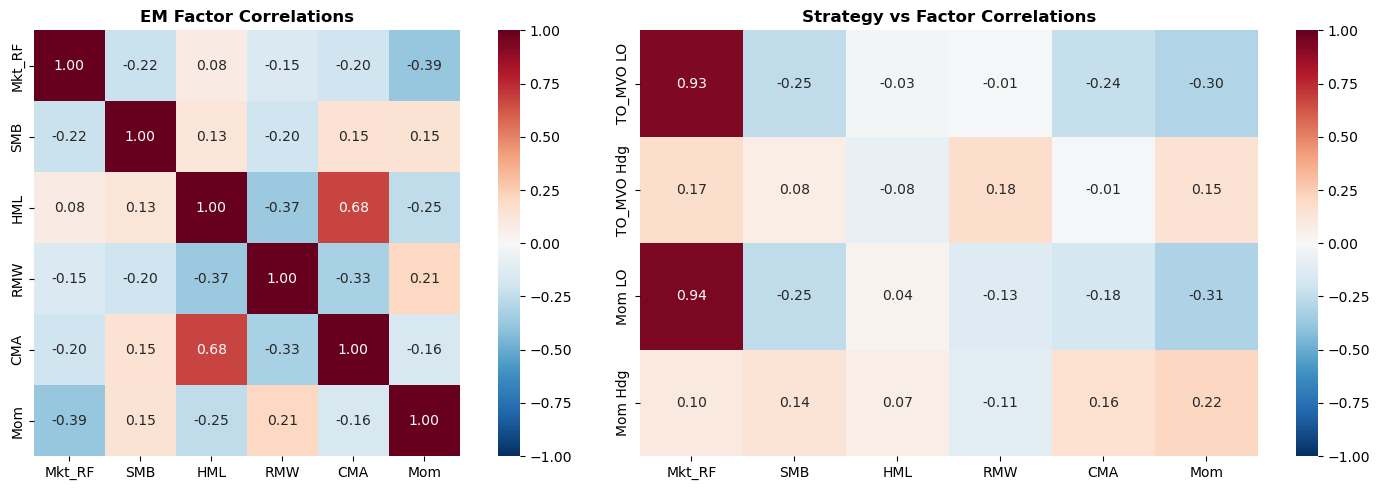

In [2]:
# Factor summary stats
factor_cols = ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
f_stats = f[factor_cols].copy()

summary = pd.DataFrame({
    'Mean (ann %)': f_stats.mean() * 12 * 100,
    'Vol (ann %)': f_stats.std() * np.sqrt(12) * 100,
    'Sharpe': f_stats.mean() * 12 / (f_stats.std() * np.sqrt(12)),
    'Min (%)': f_stats.min() * 100,
    'Max (%)': f_stats.max() * 100,
    'Skew': f_stats.skew(),
})
print('EM FACTOR SUMMARY STATISTICS')
print('='*70)
print(summary.to_string(float_format=lambda x: f'{x:.2f}'))

# Correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Factor-factor correlation
corr_ff = f_stats.corr()
sns.heatmap(corr_ff, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0], square=True)
axes[0].set_title('EM Factor Correlations', fontweight='bold')

# Strategy vs factor correlations
strat_series = {
    'TO_MVO LO': h['A_long_excess'].dropna(),
    'TO_MVO Hdg': h['A_hedged_eem'].dropna(),
    'Mom LO': h['B_long_excess'].dropna(),
    'Mom Hdg': h['B_hedged_eem'].dropna(),
}

corr_data = {}
for name, s in strat_series.items():
    common_idx = s.index.intersection(f_stats.index)
    corr_data[name] = {fc: s.loc[common_idx].corr(f_stats.loc[common_idx, fc]) for fc in factor_cols}
corr_sf = pd.DataFrame(corr_data).T
sns.heatmap(corr_sf, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Strategy vs Factor Correlations', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb16_factor_correlations.pdf', bbox_inches='tight')
plt.show()

## 3. Full-Sample Factor Regressions — Long-Only TO\_MVO

Dependent variable: $R_{p,t} - R_{f,t}$ (excess return over risk-free rate).
We must subtract RF because the long-only portfolio is fully invested.

In [3]:
def run_factor_regression(y, X_cols, factors_df, annualize_alpha=True):
    """Run OLS factor regression. Returns statsmodels result."""
    common = y.dropna().index.intersection(factors_df.index)
    y_clean = y.loc[common]
    X = factors_df.loc[common, X_cols].copy()
    X = sm.add_constant(X)
    model = sm.OLS(y_clean, X).fit(cov_type='HC1')
    return model

def print_factor_table(models, model_names, dep_var_name, factor_labels=None):
    """Print academic-style regression table using summary_col."""
    if factor_labels is None:
        factor_labels = {'const': 'Alpha (ann.)', 'Mkt_RF': 'Beta Market',
                         'SMB': 'Beta Size', 'HML': 'Beta Value',
                         'RMW': 'Beta Profitability', 'CMA': 'Beta Investment',
                         'Mom': 'Beta Momentum'}
    
    # Rename coefficients for display
    renamed_models = []
    for m in models:
        params = m.params.copy()
        if 'const' in params.index:
            params['const'] = params['const'] * 12  # annualize alpha
        bse = m.bse.copy()
        if 'const' in bse.index:
            bse['const'] = bse['const'] * 12
        renamed_models.append(m)
    
    regressor_order = ['const', 'Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
    
    tbl = summary_col(models, model_names=model_names,
                       stars=True, float_format='%.4f',
                       regressor_order=regressor_order,
                       info_dict={'R²': lambda x: f'{x.rsquared:.3f}',
                                  'N': lambda x: f'{int(x.nobs)}'})
    
    print(f'\nDEPENDENT VARIABLE: {dep_var_name}')
    print('='*90)
    print(tbl)
    
    # Also print annualized alpha with t-stats
    print(f'\nAnnualized Alpha (const × 12):')
    for name, m in zip(model_names, models):
        alpha = m.params['const'] * 12
        t = m.tvalues['const']
        p = m.pvalues['const']
        stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
        print(f'  {name:12s}: {alpha:.4f} ({alpha*100:.2f}%), t={t:.2f}, p={p:.4f} {stars}')
    print(f'\nR² across models:')
    for name, m in zip(model_names, models):
        print(f'  {name:12s}: {m.rsquared:.3f} ({m.rsquared*100:.1f}%)')

# Define model specifications
model_specs = [
    ('CAPM',     ['Mkt_RF']),
    ('FF3',      ['Mkt_RF', 'SMB', 'HML']),
    ('FF5',      ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA']),
    ('FF5+Mom',  ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']),
    ('FF3+Mom',  ['Mkt_RF', 'SMB', 'HML', 'Mom']),
    ('CAPM+Mom', ['Mkt_RF', 'Mom']),
]

# Long-only TO_MVO
y_lo_a = h['A_long_excess'].dropna()
models_lo_a = [run_factor_regression(y_lo_a, spec[1], f) for spec in model_specs]
print_factor_table(models_lo_a, [s[0] for s in model_specs],
                    'TO_MVO Long-Only Excess Return (R_p - RF)')


DEPENDENT VARIABLE: TO_MVO Long-Only Excess Return (R_p - RF)

                  CAPM      FF3        FF5      FF5+Mom    FF3+Mom   CAPM+Mom
-----------------------------------------------------------------------------
const          0.0021    0.0031**   0.0019     0.0010     0.0020    0.0008   
               (0.0015)  (0.0015)   (0.0015)   (0.0016)   (0.0017)  (0.0016) 
Mkt_RF         0.9847*** 0.9861***  1.0254***  1.0465***  1.0064*** 1.0158***
               (0.0448)  (0.0366)   (0.0383)   (0.0390)   (0.0363)  (0.0421) 
SMB                      -0.0957    -0.0287    -0.0489    -0.1136            
                         (0.1005)   (0.1039)   (0.1073)   (0.1030)           
HML                      -0.2081*** -0.2441*** -0.2339*** -0.1807**          
                         (0.0716)   (0.0772)   (0.0774)   (0.0791)           
RMW                                 0.4131***  0.3946***                     
                                    (0.1297)   (0.1319)                      


## 4. Full-Sample Factor Regressions — Hedged TO\_MVO

Dependent variable: $R_{h,t}$ (raw hedged return, no RF subtraction needed).
This is the **most important table** — it tests whether the hedged alpha
survives after controlling for all six known EM factor premia.

In [4]:
# Hedged TO_MVO
y_hd_a = h['A_hedged_eem'].dropna()
models_hd_a = [run_factor_regression(y_hd_a, spec[1], f) for spec in model_specs]
print_factor_table(models_hd_a, [s[0] for s in model_specs],
                    'TO_MVO EEM-Hedged Return (R_h)')


DEPENDENT VARIABLE: TO_MVO EEM-Hedged Return (R_h)

                 CAPM     FF3       FF5     FF5+Mom   FF3+Mom   CAPM+Mom
------------------------------------------------------------------------
const          0.0026   0.0033   0.0025    0.0006    0.0012    0.0007   
               (0.0019) (0.0020) (0.0019)  (0.0021)  (0.0022)  (0.0019) 
Mkt_RF         0.0707   0.0841*  0.1189*** 0.1603*** 0.1220*** 0.1131***
               (0.0430) (0.0466) (0.0451)  (0.0450)  (0.0452)  (0.0415) 
SMB                     0.1914   0.2620*   0.2294    0.1634             
                        (0.1376) (0.1391)  (0.1395)  (0.1377)           
HML                     -0.0833  -0.1628   -0.1525   -0.0392            
                        (0.0927) (0.1024)  (0.0999)  (0.0974)           
RMW                              0.4047**  0.3643**                     
                                 (0.1744)  (0.1673)                     
CMA                              0.2705*   0.3196*                     

## 5. Factor Regressions — Momentum Strategy (Long-Only & Hedged)

Side-by-side comparison with the Momentum portfolio construction method.

In [5]:
# Long-only Momentum
y_lo_b = h['B_long_excess'].dropna()
models_lo_b = [run_factor_regression(y_lo_b, spec[1], f) for spec in model_specs]
print_factor_table(models_lo_b, [s[0] for s in model_specs],
                    'Momentum Long-Only Excess Return (R_p - RF)')

print('\n' + '='*90 + '\n')

# Hedged Momentum
y_hd_b = h['B_hedged_eem'].dropna()
models_hd_b = [run_factor_regression(y_hd_b, spec[1], f) for spec in model_specs]
print_factor_table(models_hd_b, [s[0] for s in model_specs],
                    'Momentum EEM-Hedged Return (R_h)')


DEPENDENT VARIABLE: Momentum Long-Only Excess Return (R_p - RF)

                  CAPM      FF3       FF5     FF5+Mom   FF3+Mom   CAPM+Mom
--------------------------------------------------------------------------
const          0.0019    0.0023    0.0024    0.0010    0.0009    0.0008   
               (0.0014)  (0.0014)  (0.0015)  (0.0015)  (0.0015)  (0.0015) 
Mkt_RF         0.9813*** 0.9747*** 0.9964*** 1.0280*** 0.9996*** 1.0097***
               (0.0437)  (0.0430)  (0.0420)  (0.0438)  (0.0452)  (0.0450) 
SMB                      -0.1271   -0.1291   -0.1594   -0.1491            
                         (0.1170)  (0.1181)  (0.1164)  (0.1148)           
HML                      -0.0672   -0.1875** -0.1722** -0.0336            
                         (0.0687)  (0.0847)  (0.0811)  (0.0716)           
RMW                                -0.0130   -0.0406                      
                                   (0.1168)  (0.1173)                     
CMA                               

### Summary: Alpha Comparison

In [6]:
# Consolidated alpha comparison
print('ALPHA COMPARISON: FF5+Mom Model')
print('='*70)
print(f'{"Strategy":20s} {"Alpha (ann)":>12s} {"t-stat":>8s} {"p-value":>8s} {"R²":>6s}  Sig?')
print('-'*70)
for name, m_list in [('TO_MVO LO', models_lo_a), ('TO_MVO Hedged', models_hd_a),
                      ('Momentum LO', models_lo_b), ('Momentum Hedged', models_hd_b)]:
    m = m_list[3]  # FF5+Mom
    alpha = m.params['const'] * 12
    t = m.tvalues['const']
    p = m.pvalues['const']
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    print(f'{name:20s} {alpha:>11.2%} {t:>8.2f} {p:>8.4f} {m.rsquared:>5.1%}  {stars}')

print(f'\nKey: *** p<0.01, ** p<0.05, * p<0.10')

ALPHA COMPARISON: FF5+Mom Model
Strategy              Alpha (ann)   t-stat  p-value     R²  Sig?
----------------------------------------------------------------------
TO_MVO LO                  1.14%     0.60   0.5452 89.5%  
TO_MVO Hedged              0.70%     0.28   0.7779 17.3%  
Momentum LO                1.17%     0.65   0.5176 89.7%  
Momentum Hedged            0.59%     0.28   0.7795 19.0%  

Key: *** p<0.01, ** p<0.05, * p<0.10


## 6. Rolling Factor Loadings (36-Month Window)

Time-varying factor exposures using the full FF5+Mom model.
Tests whether factor loadings and alpha are stable over time.

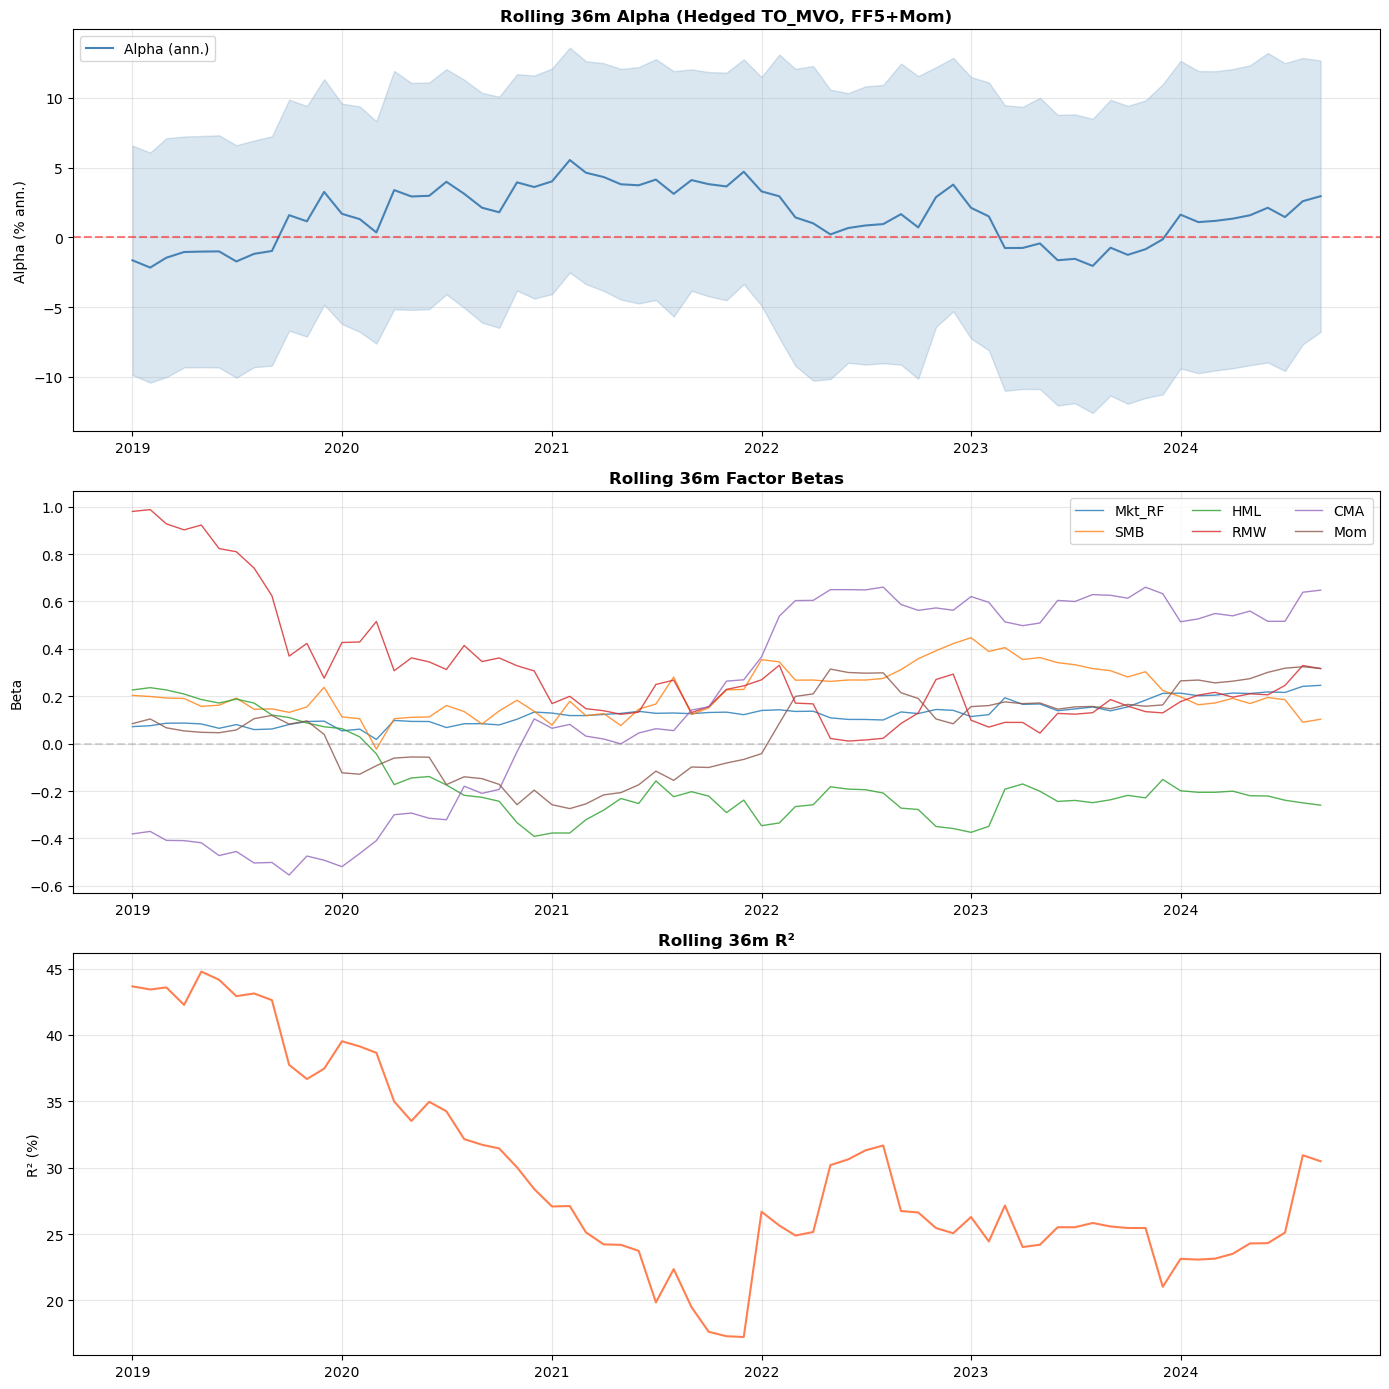

ROLLING FACTOR LOADING SUMMARY (Hedged TO_MVO)
  Alpha   : mean=1.52%, std=2.03%, min=-2.16%, max=5.54%
  Mkt_RF  : mean=0.13, std=0.05, min=0.02, max=0.25
  SMB     : mean=0.21, std=0.10, min=-0.02, max=0.45
  HML     : mean=-0.16, std=0.17, min=-0.39, max=0.24
  RMW     : mean=0.30, std=0.25, min=0.01, max=0.99
  CMA     : mean=0.17, std=0.44, min=-0.55, max=0.66
  Mom     : mean=0.06, std=0.18, min=-0.27, max=0.32
  R2      : mean=29.49%, std=7.42%, min=17.24%, max=44.77%

  Alpha positive: 72.5% of rolling windows


In [7]:
def rolling_factor_regression(y, X_cols, factors_df, window=36, min_obs=24):
    """Run rolling OLS regressions."""
    common = y.dropna().index.intersection(factors_df.index)
    y_clean = y.reindex(common)
    X_all = factors_df.reindex(common)[X_cols]
    
    dates = sorted(common)
    results = []
    for i in range(window, len(dates)+1):
        idx = dates[max(0, i-window):i]
        if len(idx) < min_obs:
            continue
        yi = y_clean.loc[idx].dropna()
        Xi = sm.add_constant(X_all.loc[yi.index])
        if len(yi) < min_obs:
            continue
        try:
            m = sm.OLS(yi, Xi).fit()
            row = {'date': idx[-1], 'Alpha': m.params['const'] * 12, 'R2': m.rsquared}
            for c in X_cols:
                row[c] = m.params.get(c, np.nan)
            row['Alpha_tstat'] = m.tvalues['const']
            row['Alpha_se'] = m.bse['const'] * 12
            results.append(row)
        except:
            pass
    return pd.DataFrame(results).set_index('date')

ff6_cols = ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']

# Rolling for hedged TO_MVO
roll_hd_a = rolling_factor_regression(h['A_hedged_eem'], ff6_cols, f, window=36)

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Panel 1: Rolling alpha with confidence bands
ax = axes[0]
ax.plot(roll_hd_a.index, roll_hd_a['Alpha']*100, lw=1.5, color='steelblue', label='Alpha (ann.)')
upper = (roll_hd_a['Alpha'] + 1.96*roll_hd_a['Alpha_se'])*100
lower = (roll_hd_a['Alpha'] - 1.96*roll_hd_a['Alpha_se'])*100
ax.fill_between(roll_hd_a.index, lower, upper, alpha=0.2, color='steelblue')
ax.axhline(y=0, color='red', ls='--', alpha=0.5)
ax.set_title('Rolling 36m Alpha (Hedged TO_MVO, FF5+Mom)', fontweight='bold')
ax.set_ylabel('Alpha (% ann.)'); ax.legend(); ax.grid(True, alpha=0.3)

# Panel 2: Rolling betas
ax = axes[1]
for col in ff6_cols:
    ax.plot(roll_hd_a.index, roll_hd_a[col], lw=1, alpha=0.8, label=col)
ax.axhline(y=0, color='gray', ls='--', alpha=0.3)
ax.set_title('Rolling 36m Factor Betas', fontweight='bold')
ax.set_ylabel('Beta'); ax.legend(ncol=3); ax.grid(True, alpha=0.3)

# Panel 3: Rolling R²
ax = axes[2]
ax.plot(roll_hd_a.index, roll_hd_a['R2']*100, lw=1.5, color='coral')
ax.set_title('Rolling 36m R²', fontweight='bold')
ax.set_ylabel('R² (%)'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb16_rolling_loadings.pdf', bbox_inches='tight')
plt.show()

# Print summary
print('ROLLING FACTOR LOADING SUMMARY (Hedged TO_MVO)')
print('='*60)
for col in ['Alpha'] + ff6_cols + ['R2']:
    s = roll_hd_a[col]
    unit = '%' if col in ['Alpha', 'R2'] else ''
    mult = 100 if col in ['Alpha', 'R2'] else 1
    print(f'  {col:8s}: mean={s.mean()*mult:.2f}{unit}, std={s.std()*mult:.2f}{unit}, '
          f'min={s.min()*mult:.2f}{unit}, max={s.max()*mult:.2f}{unit}')
# Alpha positive fraction
pos = (roll_hd_a['Alpha'] > 0).mean()
print(f'\n  Alpha positive: {pos:.1%} of rolling windows')

## 7. Expected Return Decomposition

Decompose the strategy's expected return into contributions from each factor
using rolling betas multiplied by factor risk premia.

EXPECTED RETURN DECOMPOSITION (Hedged TO_MVO, FF5+Mom)
  Alpha       :    0.70% ( 18.9% of total)
  Mkt_RF      :    0.72% ( 19.2% of total)
  SMB         :   -0.14% ( -3.8% of total)
  HML         :   -0.96% (-25.7% of total)
  RMW         :    0.97% ( 26.0% of total)
  CMA         :    0.64% ( 17.2% of total)
  Mom         :    1.80% ( 48.2% of total)
  Total       :    3.73%


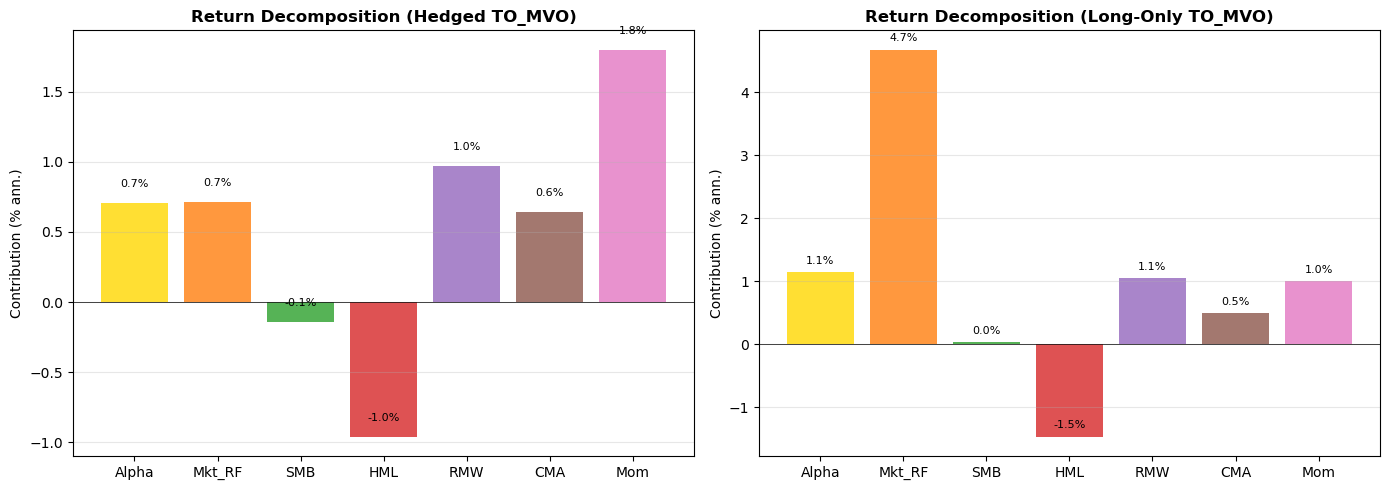

In [8]:
# Use full-sample betas × full-sample factor means for the decomposition
m_ff6_hd = models_hd_a[3]  # FF5+Mom hedged TO_MVO

alpha_ann = m_ff6_hd.params['const'] * 12
decomp = {'Alpha': alpha_ann}
for fc in ff6_cols:
    beta_i = m_ff6_hd.params[fc]
    factor_mean = f[fc].mean() * 12
    decomp[fc] = beta_i * factor_mean

decomp_df = pd.Series(decomp)
total = decomp_df.sum()

print('EXPECTED RETURN DECOMPOSITION (Hedged TO_MVO, FF5+Mom)')
print('='*60)
for k, v in decomp.items():
    print(f'  {k:12s}: {v:>8.2%} ({v/total*100:>5.1f}% of total)')
print(f'  {"Total":12s}: {total:>8.2%}')

# Stacked bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LHS: Decomposition bar
ax = axes[0]
components = ['Alpha', 'Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
vals = [decomp[c] * 100 for c in components]
colors = ['gold' if c == 'Alpha' else plt.cm.tab10(i) for i, c in enumerate(components)]
bars = ax.bar(components, vals, color=colors, alpha=0.8)
ax.axhline(y=0, color='k', lw=0.5)
ax.set_title('Return Decomposition (Hedged TO_MVO)', fontweight='bold')
ax.set_ylabel('Contribution (% ann.)')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

# RHS: Same for long-only
m_ff6_lo = models_lo_a[3]
decomp_lo = {'Alpha': m_ff6_lo.params['const'] * 12}
for fc in ff6_cols:
    decomp_lo[fc] = m_ff6_lo.params[fc] * f[fc].mean() * 12
vals_lo = [decomp_lo[c] * 100 for c in components]
bars2 = axes[1].bar(components, vals_lo, color=colors, alpha=0.8)
axes[1].axhline(y=0, color='k', lw=0.5)
axes[1].set_title('Return Decomposition (Long-Only TO_MVO)', fontweight='bold')
axes[1].set_ylabel('Contribution (% ann.)')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, vals_lo):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb16_return_decomposition.pdf', bbox_inches='tight')
plt.show()

## 8. Sub-Period Analysis

Split into development (2016–2018) and holdout (2019–2024) to test alpha persistence.

In [9]:
# Sub-period regressions
periods = {
    'Dev (2016-18)': (pd.Timestamp('2016-01-01'), pd.Timestamp('2018-12-31')),
    'Holdout (2019-24)': (pd.Timestamp('2019-01-01'), pd.Timestamp('2024-12-31')),
    'Full Sample': (pd.Timestamp('2014-01-01'), pd.Timestamp('2025-12-31')),
}

for strat_name, y_series, dep_label in [
    ('TO_MVO Hedged', h['A_hedged_eem'], 'R_h'),
    ('TO_MVO Long-Only', h['A_long_excess'], 'R_p - RF'),
]:
    print(f'\n{"="*70}')
    print(f'SUB-PERIOD ANALYSIS: {strat_name}')
    print(f'{"="*70}')
    sub_models = []
    sub_names = []
    for pname, (start, end) in periods.items():
        y_sub = y_series[(y_series.index >= start) & (y_series.index <= end)].dropna()
        if len(y_sub) < 12:
            print(f'  {pname}: too few obs ({len(y_sub)})')
            continue
        m = run_factor_regression(y_sub, ff6_cols, f)
        sub_models.append(m)
        sub_names.append(pname)
    
    if sub_models:
        print_factor_table(sub_models, sub_names, f'{strat_name} ({dep_label})')


SUB-PERIOD ANALYSIS: TO_MVO Hedged

DEPENDENT VARIABLE: TO_MVO Hedged (R_h)

               Dev (2016-18) Holdout (2019-24) Full Sample
----------------------------------------------------------
const          -0.0020       0.0020            0.0006     
               (0.0035)      (0.0024)          (0.0021)   
Mkt_RF         0.0614        0.1637***         0.1603***  
               (0.0918)      (0.0561)          (0.0450)   
SMB            0.2562        0.0986            0.2294     
               (0.2301)      (0.1795)          (0.1395)   
HML            0.2675        -0.1611           -0.1525    
               (0.2539)      (0.1324)          (0.0999)   
RMW            0.9330**      0.1724            0.3643**   
               (0.3894)      (0.1932)          (0.1673)   
CMA            -0.4013       0.4304**          0.3196*    
               (0.3828)      (0.1730)          (0.1655)   
Mom            0.1347        0.1692*           0.1812**   
               (0.2142)      (0.0996)

## 9. GRS Test (Joint Alpha Significance)

The Gibbons-Ross-Shanken (1989) test jointly tests whether
$\alpha = 0$ across multiple test assets given the factor model.
We apply it to the 11 industry factor portfolios to test whether
the factor model fully explains cross-industry return variation.

INDUSTRY-LEVEL ALPHAS (FF5+Mom, Full Sample)
Industry         Alpha (ann)   t-stat  p-value     R²
----------------------------------------------------------------------
BMATR                -5.71%    -1.05   0.2932 61.5% 
CODIS                 4.62%     1.20   0.2291 71.9% 
COSTP                 1.24%     0.33   0.7388 56.9% 
ENEGY                -1.79%    -0.33   0.7451 55.7% 
FINAN                -0.76%    -0.32   0.7473 85.6% 
HLTHC                 5.91%     1.02   0.3090 40.0% 
INDUS                -1.38%    -0.36   0.7214 68.9% 
RLEST                11.40%     1.16   0.2443 55.8% 
TECNO                 3.70%     1.08   0.2817 76.0% 
TELCM                 4.70%     0.92   0.3591 56.1% 
UTILS                -2.37%    -0.36   0.7189 42.8% 

GRS TEST:
  F-stat: 1.161
  p-value: 0.3216
  → FAIL TO REJECT H0: industry alphas are not jointly significant
    The FF5+Mom model may adequately explain cross-industry returns


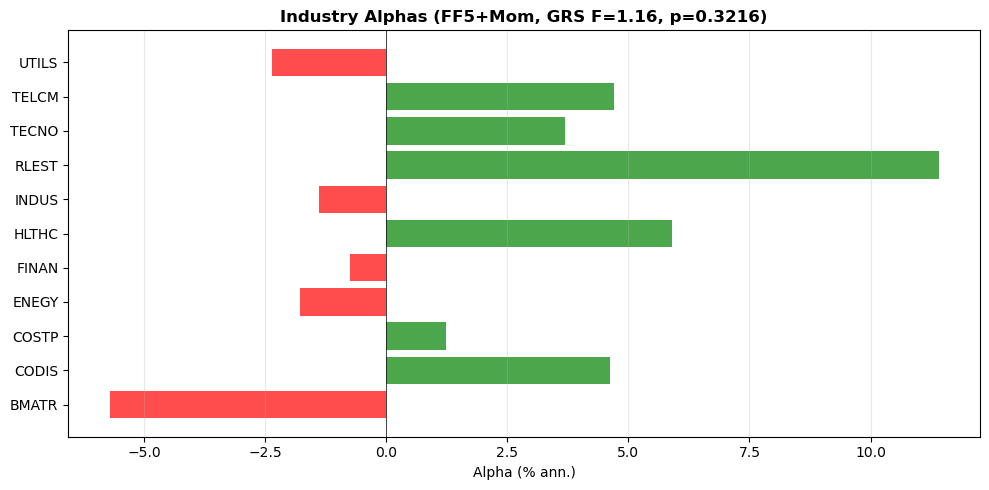

In [10]:
def grs_test(alphas, sigma_eps, sigma_f, T, N, K):
    """
    GRS test statistic.
    alphas: N×1 vector of alphas
    sigma_eps: N×N residual covariance
    sigma_f: K×K factor covariance
    T, N, K: sample size, number of assets, number of factors
    """
    sigma_eps_inv = np.linalg.inv(sigma_eps)
    sigma_f_inv = np.linalg.inv(sigma_f)
    f_bar = np.zeros(K)  # already demeaned in regression
    
    # GRS = (T/N) * ((T-N-K)/(T-K-1)) * (alpha' Sigma_eps^{-1} alpha) / (1 + f_bar' Sigma_f^{-1} f_bar)
    # Simplified when using excess returns
    grs_stat = ((T - N - K) / N) * (alphas @ sigma_eps_inv @ alphas) / (1 + f_bar @ sigma_f_inv @ f_bar)
    
    from scipy.stats import f as f_dist
    p_value = 1 - f_dist.cdf(grs_stat, N, T - N - K)
    return grs_stat, p_value

# Run FF5+Mom regression on each of the 11 industry factor portfolios
ind_ret = pd.read_csv(f'{OUTPUT_DIR}/csv/composite_all6_ew_industry_returns.csv', index_col=0, parse_dates=True)
ind_common = ind_ret.index.intersection(f.index)
ind_r = ind_ret.loc[ind_common]
f_common = f.loc[ind_common]

# Subtract RF for industry portfolios (they are fully invested)
ind_excess = ind_r.sub(f_common['RF'], axis=0)

industry_models = {}
for ind_col in ind_excess.columns:
    y = ind_excess[ind_col].dropna()
    m = run_factor_regression(y, ff6_cols, f)
    industry_models[ind_col] = m

# Print industry-level alpha table
print('INDUSTRY-LEVEL ALPHAS (FF5+Mom, Full Sample)')
print('='*70)
print(f'{"Industry":15s} {"Alpha (ann)":>12s} {"t-stat":>8s} {"p-value":>8s} {"R²":>6s}')
print('-'*70)
for ind, m in industry_models.items():
    alpha = m.params['const'] * 12
    t = m.tvalues['const']
    p = m.pvalues['const']
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    print(f'{ind:15s} {alpha:>11.2%} {t:>8.2f} {p:>8.4f} {m.rsquared:>5.1%} {stars}')

# GRS test
N = len(industry_models)
K = len(ff6_cols)
T = len(ind_common)
alphas = np.array([m.params['const'] for m in industry_models.values()])
residuals = np.column_stack([m.resid for m in industry_models.values()])
sigma_eps = np.cov(residuals.T)
sigma_f = np.cov(f_common[ff6_cols].values.T)

grs_stat, grs_p = grs_test(alphas, sigma_eps, sigma_f, T, N, K)
print(f'\nGRS TEST:')
print(f'  F-stat: {grs_stat:.3f}')
print(f'  p-value: {grs_p:.4f}')
if grs_p < 0.05:
    print(f'  → REJECT H0: industry alphas are jointly significantly different from zero')
    print(f'    The FF5+Mom model does NOT fully explain cross-industry return variation')
else:
    print(f'  → FAIL TO REJECT H0: industry alphas are not jointly significant')
    print(f'    The FF5+Mom model may adequately explain cross-industry returns')

fig, ax = plt.subplots(figsize=(10, 5))
inds = list(industry_models.keys())
alpha_vals = [industry_models[i].params['const']*12*100 for i in inds]
colors = ['green' if a > 0 else 'red' for a in alpha_vals]
ax.barh(inds, alpha_vals, color=colors, alpha=0.7)
ax.axvline(x=0, color='k', lw=0.5)
ax.set_title(f'Industry Alphas (FF5+Mom, GRS F={grs_stat:.2f}, p={grs_p:.4f})', fontweight='bold')
ax.set_xlabel('Alpha (% ann.)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb16_industry_alphas.pdf', bbox_inches='tight')
plt.show()

## 10. Summary and Interpretation

In [11]:
print('='*70)
print('FACTOR MODEL ANALYSIS — CONSOLIDATED SUMMARY')
print('='*70)

# Collect key results from FF5+Mom model
results = {}
for name, m in [('TO_MVO LO', models_lo_a[3]), ('TO_MVO Hdg', models_hd_a[3]),
                 ('Mom LO', models_lo_b[3]), ('Mom Hdg', models_hd_b[3])]:
    results[name] = {
        'Alpha (ann)': m.params['const'] * 12,
        'Alpha t': m.tvalues['const'],
        'Alpha p': m.pvalues['const'],
        'Beta Mkt': m.params['Mkt_RF'],
        'Beta SMB': m.params['SMB'],
        'Beta HML': m.params['HML'],
        'Beta RMW': m.params['RMW'],
        'Beta CMA': m.params['CMA'],
        'Beta Mom': m.params['Mom'],
        'R²': m.rsquared,
    }

rdf = pd.DataFrame(results).T
print(rdf.to_string(float_format=lambda x: f'{x:.3f}'))

print(f'\n--- INTERPRETATION ---')
print(f'')
print(f'1. ALPHA SIGNIFICANCE:')
for name in rdf.index:
    r = rdf.loc[name]
    sig = '***' if r['Alpha p'] < 0.01 else '**' if r['Alpha p'] < 0.05 else '*' if r['Alpha p'] < 0.10 else 'not sig'
    print(f'   {name:15s}: alpha={r["Alpha (ann)"]:.2%}, t={r["Alpha t"]:.2f} ({sig})')

print(f'')
print(f'2. FACTOR LOADINGS (Hedged TO_MVO, FF5+Mom):')
m = models_hd_a[3]
for fc, label in [('Mkt_RF', 'Market'), ('SMB', 'Size'), ('HML', 'Value'),
                    ('RMW', 'Profitability'), ('CMA', 'Investment'), ('Mom', 'Momentum')]:
    b = m.params[fc]; t = m.tvalues[fc]; p = m.pvalues[fc]
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else 'ns'
    print(f'   {label:15s}: beta={b:.3f}, t={t:.2f} ({sig})')

print(f'')
print(f'3. WHAT THIS MEANS:')
print(f'   - If Market beta ≈ 0: hedge is effective (market-neutral confirmed)')
print(f'   - If alpha significant: strategy generates returns BEYOND factor tilts')
print(f'   - If R² is low: most return variation is idiosyncratic (not explained by FF factors)')
print(f'   - If alpha stable in rolling windows: the alpha is persistent, not a one-time event')
print(f'   - GRS test on industries: tests if factor model explains the cross-industry return structure')

# Save results
rdf.to_csv(f'{OUTPUT_DIR}/csv/nb16_factor_model_results.csv')
print(f'\nResults saved to {OUTPUT_DIR}/csv/nb16_factor_model_results.csv')

FACTOR MODEL ANALYSIS — CONSOLIDATED SUMMARY
            Alpha (ann)  Alpha t  Alpha p  Beta Mkt  Beta SMB  Beta HML  Beta RMW  Beta CMA  Beta Mom    R²
TO_MVO LO         0.011    0.605    0.545     1.046    -0.049    -0.234     0.395     0.244     0.101 0.895
TO_MVO Hdg        0.007    0.282    0.778     0.160     0.229    -0.153     0.364     0.320     0.181 0.173
Mom LO            0.012    0.647    0.518     1.028    -0.159    -0.172    -0.041     0.271     0.151 0.897
Mom Hdg           0.006    0.280    0.780     0.132     0.154    -0.137    -0.090     0.373     0.249 0.190

--- INTERPRETATION ---

1. ALPHA SIGNIFICANCE:
   TO_MVO LO      : alpha=1.14%, t=0.60 (not sig)
   TO_MVO Hdg     : alpha=0.70%, t=0.28 (not sig)
   Mom LO         : alpha=1.17%, t=0.65 (not sig)
   Mom Hdg        : alpha=0.59%, t=0.28 (not sig)

2. FACTOR LOADINGS (Hedged TO_MVO, FF5+Mom):
   Market         : beta=0.160, t=3.56 (***)
   Size           : beta=0.229, t=1.64 (ns)
   Value          : beta=-0.153,